### Analysed 5 years of NPCI UPI data and correlated it with India's GDP growth using the World Bank API. As India's economy grew from $3.1T to $3.9T, UPI transaction value grew proportionally. Built end to end in Python on real government data.

In [217]:
import pandas as pd
import glob
import os

In [218]:
print(os.getcwd())

C:\Users\Rishitha\Downloads\Product statistics- UPI


In [220]:
#load all Excel files
os.chdir(r"C:\Users\Rishitha\Downloads\Product statistics- UPI")

print(os.getcwd())
files = glob.glob("*.xlsx")
print(files)

C:\Users\Rishitha\Downloads\Product statistics- UPI
['Product-Statistics-UPI-Upi-monthly-statistics-2021-22-monthly.xlsx', 'Product-Statistics-UPI-Upi-monthly-statistics-2022-23-monthly.xlsx', 'Product-Statistics-UPI-Upi-monthly-statistics-2023-24-monthly.xlsx', 'Product-Statistics-UPI-Upi-monthly-statistics-2024-25-monthly.xlsx', 'Product-Statistics-UPI-Upi-monthly-statistics-2025-26-monthly.xlsx']


In [221]:
#load all files and combine into one dataframe
dfs=[] # created an empty list to store each file's data

for file in files: #loop through each of your 5 filenames one at a time, files is the list glob found earlier
    df = pd.read_excel(file) # open the excel file and load it into the dataframe called df
    df['source_file'] = file #tracks which year it came from, add a new column called source file that records which files in the row came from. so
    #you always know 2021 data came from the 2021 file, etc. senior analyst always track data origin.
    dfs.append(df) # puts the dataframe into the box after the loop finishes, you have 5 dataframes in the box
#combine all years
raw= pd.concat(dfs, ignore_index= True) #stack all 5 dataframes on top of each other into one single dataframe called raw. 
#ignore index resets row numbers cleanly from 0

#first look
print(raw.shape)
print(raw.columns.tolist())
print(raw.head(10))

(50, 6)
['Month', 'Volume (In Mn.)', 'Avg. Daily Volume (In Mn.)', 'Value (In Cr.)', 'Avg. Daily Value (In Cr.)', 'source_file']
            Month  Volume (In Mn.)  Avg. Daily Volume (In Mn.)  \
0      March-2022          5405.65                    174.3758   
1   February-2022          4527.49                    161.6960   
2    January-2022          4617.16                    148.9405   
3   December-2021          4566.30                    147.3000   
4   November-2021          4186.48                    139.5493   
5    October-2021          4218.64                    136.0853   
6  September-2021          3654.30                    121.8099   
7     August-2021          3555.55                    114.6950   
8       July-2021          3247.82                    104.7682   
9       June-2021          2807.52                     93.5839   

   Value (In Cr.)  Avg. Daily Value (In Cr.)  \
0       960581.67                 30986.5055   
1       826843.02                 29530.1079   


Month — time period (monthly data)
Volume (In Mn.) — number of UPI transactions that month in millions
Avg. Daily Volume — average per day that month
Value (In Cr.) — total money moved in crores
Avg. Daily Value — average money per day
source_file — which year file it came from



#### data quality issues

In [224]:
#check data types and nulls
print(raw.dtypes)
print("\n")
print(raw.isnull().sum())
print("\n")

Month                          object
Volume (In Mn.)               float64
Avg. Daily Volume (In Mn.)    float64
Value (In Cr.)                float64
Avg. Daily Value (In Cr.)     float64
source_file                    object
dtype: object


Month                         0
Volume (In Mn.)               0
Avg. Daily Volume (In Mn.)    0
Value (In Cr.)                0
Avg. Daily Value (In Cr.)     0
source_file                   0
dtype: int64




In [226]:
#duplicate check
print("=== Duplicate Rows===")
print(f"Total duplicate rows: {raw.duplicated().sum()}") #ouput 0, means no row is a exact copy of another row. All 50 rows are unique entries

=== Duplicate Rows===
Total duplicate rows: 0


In [227]:
print("===Duplicate Months Across Files===")
month_counts = raw.groupby('Month')['source_file'].count()
duplicated_months = month_counts[month_counts>1]
print(f"Months appearing in more than one file:{len(duplicated_months)}")
if len(duplicated_months)>0:
   print(duplicated_months)

===Duplicate Months Across Files===
Months appearing in more than one file:0


In [229]:
print("===Parse Month As Datetime===")
raw['Month_dt'] = pd.to_datetime(raw['Month'], format ='%B-%Y')
print("Month column successfully converted to datetime")
print(raw['Month_dt'].head(3))

===Parse Month As Datetime===
Month column successfully converted to datetime
0   2022-03-01
1   2022-02-01
2   2022-01-01
Name: Month_dt, dtype: datetime64[ns]


###### March-2022" is now stored as 2022-03-01.

In [231]:
print("===Sort Chronologically===")
raw = raw.sort_values('Month_dt').reset_index(drop=True)
print("Data sorted oldest to newest")
print(raw[['Month','Month_dt']].head(3))

===Sort Chronologically===
Data sorted oldest to newest
         Month   Month_dt
0    June-2021 2021-06-01
1    July-2021 2021-07-01
2  August-2021 2021-08-01


#####  NPCI's financial year starts in April. So the 2021-22 file starting from June just means April and May 2021 data either wasn't published yet or wasn't included.

In [233]:
print("=== Missing Months Check===")

full_range = pd.date_range(
    start = raw['Month_dt'].min(),
    end =raw['Month_dt'].max(),
    freq= 'MS'
)
missing = full_range.difference(raw['Month_dt'])
print(f"Expected months : {len(full_range)}")
print(f"Actual months: {len(raw)}")
print(f"Missing months: {len(missing)}")
if len(missing)>0:
    print("Missing:")
    print(missing)

=== Missing Months Check===
Expected months : 58
Actual months: 50
Missing months: 8
Missing:
DatetimeIndex(['2022-04-01', '2022-05-01', '2023-04-01', '2023-05-01',
               '2024-04-01', '2024-05-01', '2025-04-01', '2025-05-01'],
              dtype='datetime64[ns]', freq=None)


##### April and May data is missing for every year 2022 to 2025. This is consistent with NPCI's financial year publishing cycle


In [235]:
print()
print("=== VALUE RANGE CHECK ===")
numeric_cols = [
    'Volume (In Mn.)',
    'Avg. Daily Volume (In Mn.)',
    'Value (In Cr.)',
    'Avg. Daily Value (In Cr.)'
]
for col in numeric_cols:
    print(f"{col}:")
    print(f"  Min : {raw[col].min():,.2f}")
    print(f"  Max : {raw[col].max():,.2f}")
    print(f"  Zeros: {(raw[col] == 0).sum()}")
    print()
    
              


=== VALUE RANGE CHECK ===
Volume (In Mn.):
  Min : 2,807.52
  Max : 22,641.14
  Zeros: 0

Avg. Daily Volume (In Mn.):
  Min : 93.58
  Max : 730.36
  Zeros: 0

Value (In Cr.):
  Min : 547,373.16
  Max : 2,952,542.03
  Zeros: 0

Avg. Daily Value (In Cr.):
  Min : 18,245.77
  Max : 95,865.33
  Zeros: 0



##### UPI transaction volume grew 8x between June 2021 and 2025.

In [237]:
print("=== Descriptive Statistics===")
print(raw[numeric_cols].describe().round(2))

=== Descriptive Statistics===
       Volume (In Mn.)  Avg. Daily Volume (In Mn.)  Value (In Cr.)  \
count            50.00                       50.00           50.00   
mean          11788.46                      387.71      1699525.67   
std            6036.61                      198.63       705689.26   
min            2807.52                       93.58       547373.16   
25%            6629.92                      215.69      1083981.15   
50%           11322.04                      371.27      1727754.48   
75%           16693.75                      546.11      2342202.82   
max           22641.14                      730.36      2952542.03   

       Avg. Daily Value (In Cr.)  
count                      50.00  
mean                    55897.34  
std                     23224.79  
min                     18245.77  
25%                     35267.25  
50%                     56669.36  
75%                     75786.30  
max                     95865.33  


In [239]:
print("=== DataFrame Info===")
raw.info()

=== DataFrame Info===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Month                       50 non-null     object        
 1   Volume (In Mn.)             50 non-null     float64       
 2   Avg. Daily Volume (In Mn.)  50 non-null     float64       
 3   Value (In Cr.)              50 non-null     float64       
 4   Avg. Daily Value (In Cr.)   50 non-null     float64       
 5   source_file                 50 non-null     object        
 6   Month_dt                    50 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 2.9+ KB


In [243]:
df_clean= raw.copy()
df_clean = df_clean.rename(columns={
    'Volume (In Mn.)':'volume', 
    'Avg. Daily Volume (In Mn.)':'avg_daily_volume',
    'Value (In Cr.)': 'value',
    'Avg. Daily Value (In Cr.)':'avg_daily_value'})                 

In [244]:
print(raw.columns.tolist())

['Month', 'Volume (In Mn.)', 'Avg. Daily Volume (In Mn.)', 'Value (In Cr.)', 'Avg. Daily Value (In Cr.)', 'source_file', 'Month_dt']


In [245]:
print(df_clean.columns.tolist())

['Month', 'volume', 'avg_daily_volume', 'value', 'avg_daily_value', 'source_file', 'Month_dt']


In [246]:
print(df_clean.shape)
print(df_clean.head(3))

(50, 7)
         Month   volume  avg_daily_volume      value  avg_daily_value  \
0    June-2021  2807.52           93.5839  547373.16       18245.7720   
1    July-2021  3247.82          104.7682  605883.20       19544.6194   
2  August-2021  3555.55          114.6950  639116.95       20616.6758   

                                         source_file   Month_dt  
0  Product-Statistics-UPI-Upi-monthly-statistics-... 2021-06-01  
1  Product-Statistics-UPI-Upi-monthly-statistics-... 2021-07-01  
2  Product-Statistics-UPI-Upi-monthly-statistics-... 2021-08-01  


In [247]:
df_clean=df_clean.drop(columns =['Month'])
df_clean=df_clean.drop(columns =['source_file'])

In [248]:
print(df_clean)

      volume  avg_daily_volume       value  avg_daily_value   Month_dt
0    2807.52           93.5839   547373.16       18245.7720 2021-06-01
1    3247.82          104.7682   605883.20       19544.6194 2021-07-01
2    3555.55          114.6950   639116.95       20616.6758 2021-08-01
3    3654.30          121.8099   654648.28       21821.6093 2021-09-01
4    4218.64          136.0853   771406.99       24884.0965 2021-10-01
5    4186.48          139.5493   768436.09       25614.5363 2021-11-01
6    4566.30          147.3000   826848.23       26672.5235 2021-12-01
7    4617.16          148.9405   831993.09       26838.4868 2022-01-01
8    4527.49          161.6960   826843.02       29530.1079 2022-02-01
9    5405.65          174.3758   960581.67       30986.5055 2022-03-01
10   5862.75          195.4250  1014412.63       33813.7543 2022-06-01
11   6288.40          202.8516  1063117.04       34294.0981 2022-07-01
12   6579.63          212.2461  1073162.17       34618.1345 2022-08-01
13   6

In [249]:
df_clean['avg_transaction_value'] = df_clean['value']/df_clean['volume']
print(df_clean['avg_transaction_value'])

0     194.966789
1     186.550732
2     179.751923
3     179.144646
4     182.856795
5     183.551836
6     181.076195
7     180.195854
8     182.627244
9     177.699568
10    173.026759
11    169.060022
12    163.103726
13    164.646958
14    165.847754
15    162.883905
16    163.736190
17    161.636999
18    164.019369
19    161.761895
20    158.056216
21    153.903696
22    148.926276
23    149.600185
24    150.390036
25    154.846080
26    151.656786
27    150.871175
28    151.030256
29    147.198901
30    144.548863
31    143.000607
32    137.721626
33    137.217725
34    141.683793
35    139.205828
36    138.953888
37    138.152255
38    136.375002
39    135.356131
40    130.683848
41    128.852709
42    124.222031
43    126.811083
44    131.771472
45    128.579431
46    129.269950
47    130.554357
48    131.617288
49    130.406067
Name: avg_transaction_value, dtype: float64


In [250]:
print(df_clean.shape)
print(df_clean.columns.tolist())

(50, 6)
['volume', 'avg_daily_volume', 'value', 'avg_daily_value', 'Month_dt', 'avg_transaction_value']


In [251]:
print(df_clean.head(3))
print("\n")
print(df_clean.dtypes)

    volume  avg_daily_volume      value  avg_daily_value   Month_dt  \
0  2807.52           93.5839  547373.16       18245.7720 2021-06-01   
1  3247.82          104.7682  605883.20       19544.6194 2021-07-01   
2  3555.55          114.6950  639116.95       20616.6758 2021-08-01   

   avg_transaction_value  
0             194.966789  
1             186.550732  
2             179.751923  


volume                          float64
avg_daily_volume                float64
value                           float64
avg_daily_value                 float64
Month_dt                 datetime64[ns]
avg_transaction_value           float64
dtype: object


##### Data cleaning complete
##### 50 rows, 6 columns
##### Dropped: Month (text), source_file (origin tracker)
##### Added: avg_transaction_value (value / volume) — average rupees per transaction
##### df_clean is ready for EDA

### EDA

In [254]:
import matplotlib.pyplot as plt
# Set style
plt.style.use('seaborn-v0_8')   # clean white background

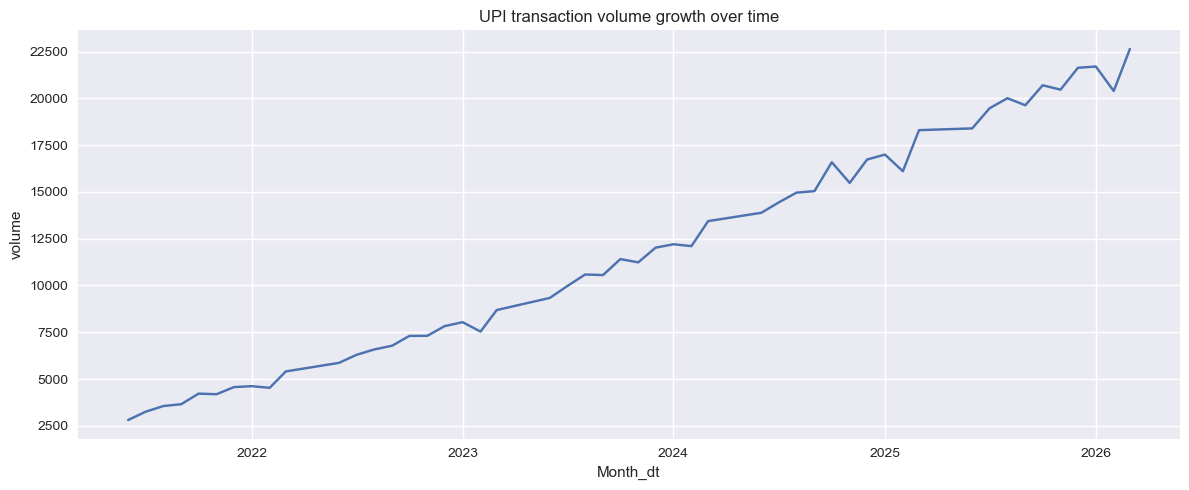

In [258]:
plt.figure(figsize = (12,5))
plt.plot(df_clean['Month_dt'],df_clean['volume'])
plt.title('UPI transaction volume growth over time')
plt.xlabel('Month_dt')
plt.ylabel('volume')
plt.tight_layout()
plt.show()

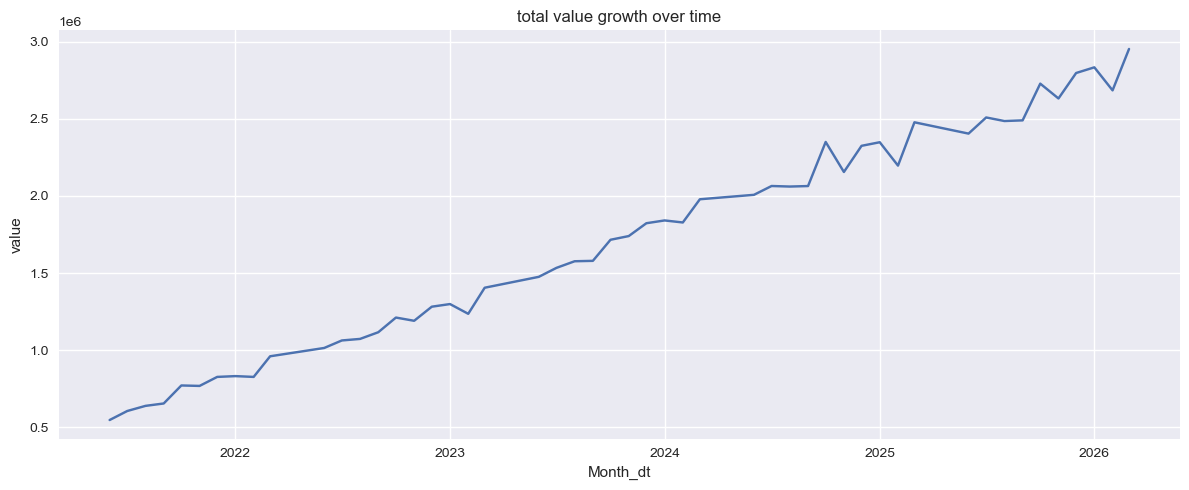

In [262]:
plt.figure(figsize =(12,5))
plt.plot(df_clean['Month_dt'],df_clean['value'])
plt.title('total value growth over time')
plt.xlabel('Month_dt')
plt.ylabel('value')
plt.tight_layout()
plt.show()

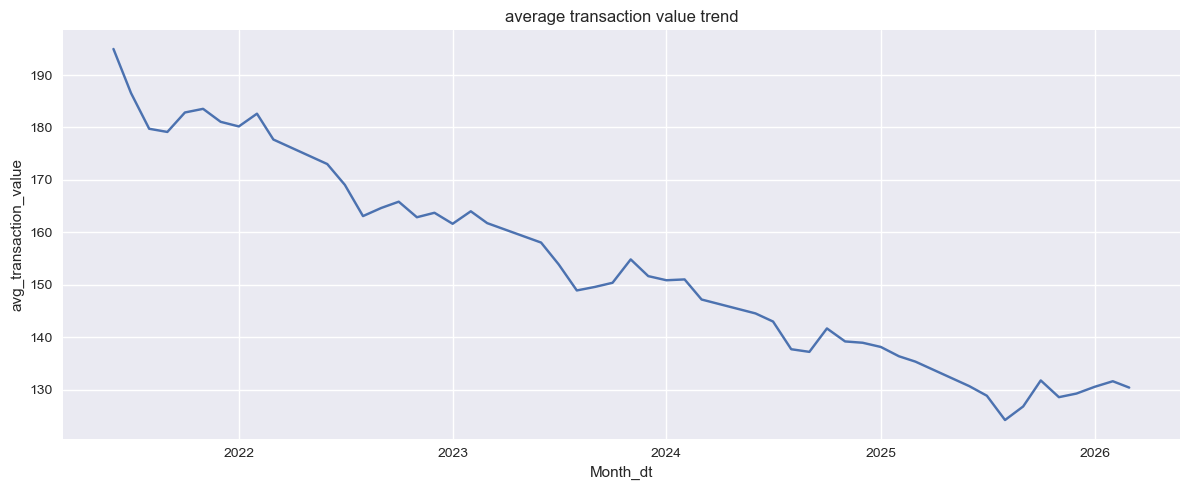

In [264]:
plt.figure(figsize =(12,5))
plt.plot(df_clean['Month_dt'], df_clean['avg_transaction_value'])
plt.title('average transaction value trend')
plt.xlabel('Month_dt')
plt.ylabel('avg_transaction_value')
plt.tight_layout()
plt.show()

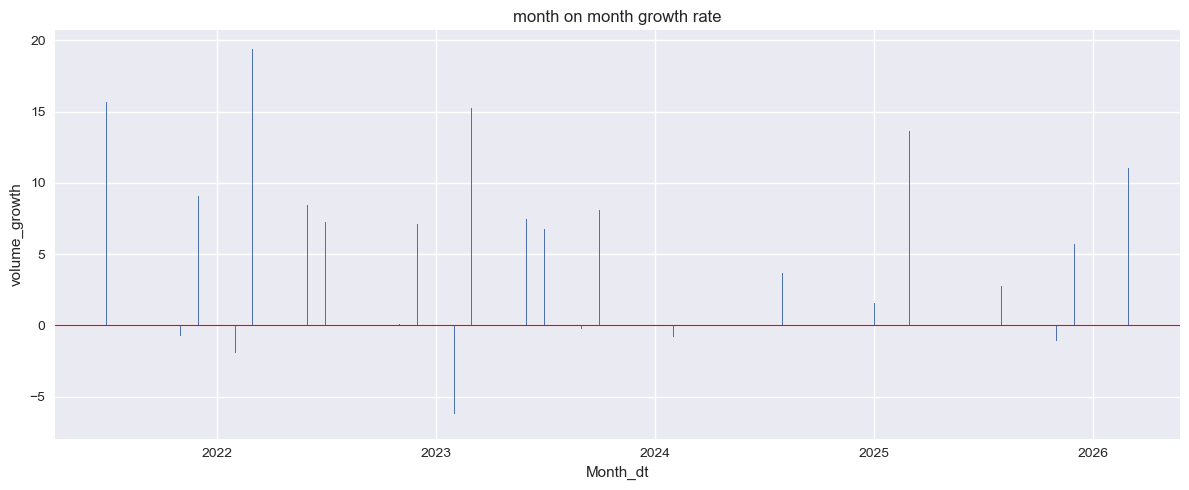

In [272]:
df_clean['volume_growth'] = df_clean['volume'].pct_change()*100
plt.figure(figsize = (12,5))
plt.bar(df_clean['Month_dt'],df_clean['volume_growth'])
plt.axhline(y=0, color ='red', linewidth =0.8)
plt.title('month on month growth rate')
plt.xlabel('Month_dt')
plt.ylabel('volume_growth')
plt.tight_layout()
plt.show()

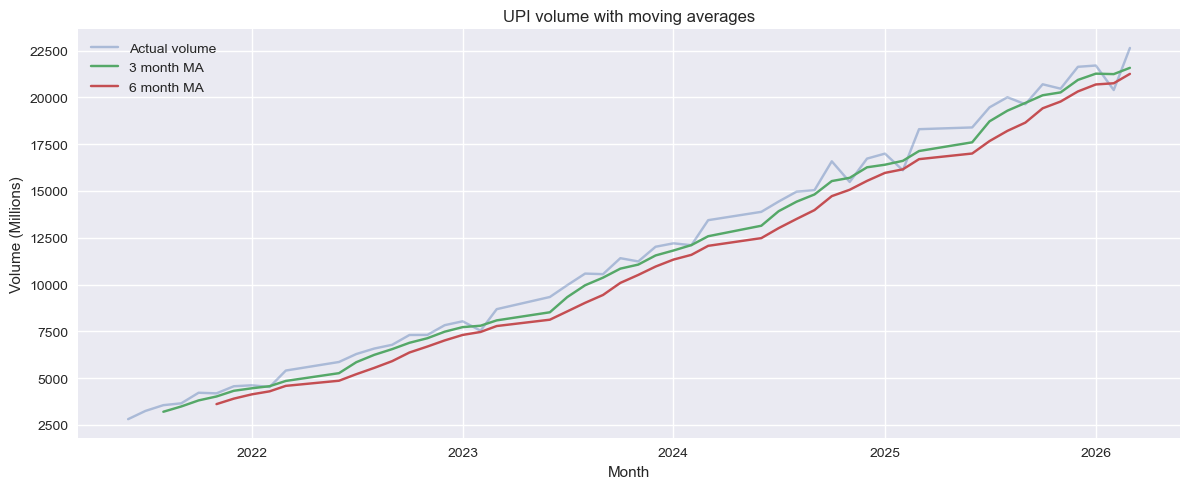

In [343]:
df_clean['volume_ma3'] = df_clean['volume'].rolling(window=3).mean()
df_clean['volume_ma6'] = df_clean['volume'].rolling(window=6).mean()

plt.figure(figsize=(12,5))
plt.plot(df_clean['Month_dt'], df_clean['volume'], alpha=0.4, label='Actual volume')
plt.plot(df_clean['Month_dt'], df_clean['volume_ma3'], label='3 month MA')
plt.plot(df_clean['Month_dt'], df_clean['volume_ma6'], label='6 month MA')
plt.title('UPI volume with moving averages')
plt.xlabel('Month')
plt.ylabel('Volume (Millions)')
plt.legend()
plt.tight_layout()
plt.show()

##### pulling world bank GDP

###### World Bank is an international organization that tracks economic data for every country in the world. GDP means Gross Domestic Product — the total value of everything India produced and sold in a year. It is the single best measure of how big and healthy an economy is.

###### Why are we merging GDP with UPI data? when India's economy grows, more money flows through digital payments. want to check:Does UPI value growth follow GDP growth?In years where GDP was high — was UPI value also high?

In [276]:
import requests

In [300]:
url = "https://api.worldbank.org/v2/country/IN/indicator/NY.GDP.MKTP.CD?date=2021:2025&format=json"

response = requests.get(url)
data = response.json()
print(type(data))
print(data[0])




<class 'list'>
{'page': 1, 'pages': 1, 'per_page': 50, 'total': 5, 'sourceid': '2', 'lastupdated': '2026-04-08'}


In [302]:
gdp_records = data[1]

gdp_list = []
for record in gdp_records:
    if record['value'] is not None:
        gdp_list.append({
            'year': int(record['date']),
            'gdp_usd': record['value']
        })

gdp_df = pd.DataFrame(gdp_list)
gdp_df = gdp_df.sort_values('year').reset_index(drop=True)
print(gdp_df)

   year       gdp_usd
0  2021  3.167271e+12
1  2022  3.346107e+12
2  2023  3.638489e+12
3  2024  3.909892e+12


In [286]:
url = "https://api.worldbank.org/v2/country/IN/indicator/NY.GDP.MKTP.CD?date=2021:2025&format=json"

response = requests.get(url)
print(response.status_code)
print(response.json())

200
[{'page': 1, 'pages': 1, 'per_page': 50, 'total': 5, 'sourceid': '2', 'lastupdated': '2026-04-08'}, [{'indicator': {'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (current US$)'}, 'country': {'id': 'IN', 'value': 'India'}, 'countryiso3code': 'IND', 'date': '2025', 'value': None, 'unit': '', 'obs_status': '', 'decimal': 0}, {'indicator': {'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (current US$)'}, 'country': {'id': 'IN', 'value': 'India'}, 'countryiso3code': 'IND', 'date': '2024', 'value': 3909891533858.08, 'unit': '', 'obs_status': '', 'decimal': 0}, {'indicator': {'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (current US$)'}, 'country': {'id': 'IN', 'value': 'India'}, 'countryiso3code': 'IND', 'date': '2023', 'value': 3638489096033.86, 'unit': '', 'obs_status': '', 'decimal': 0}, {'indicator': {'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (current US$)'}, 'country': {'id': 'IN', 'value': 'India'}, 'countryiso3code': 'IND', 'date': '2022', 'value': 3346107287730.93, 'unit': '', 'obs_status': '', 'decimal': 0},

In [304]:
df_clean['year'] = df_clean['Month_dt'].dt.year

upi_yearly = df_clean.groupby('year')[['volume','value']].sum().reset_index()
print(upi_yearly)

   year     volume        value
0  2021   26236.61   4813712.90
1  2022   62506.25  10570699.46
2  2023   99362.29  15382984.77
3  2024  144868.18  20673119.25
4  2025  191710.98  25065514.67
5  2026   64738.80   8470252.59


In [306]:
merged_df = pd.merge(upi_yearly, gdp_df, on='year', how='left')
print(merged_df)

   year     volume        value       gdp_usd
0  2021   26236.61   4813712.90  3.167271e+12
1  2022   62506.25  10570699.46  3.346107e+12
2  2023   99362.29  15382984.77  3.638489e+12
3  2024  144868.18  20673119.25  3.909892e+12
4  2025  191710.98  25065514.67           NaN
5  2026   64738.80   8470252.59           NaN


###### As India's economy grew, UPI transaction value grew with it. A stronger economy means more money flowing through digital payments.

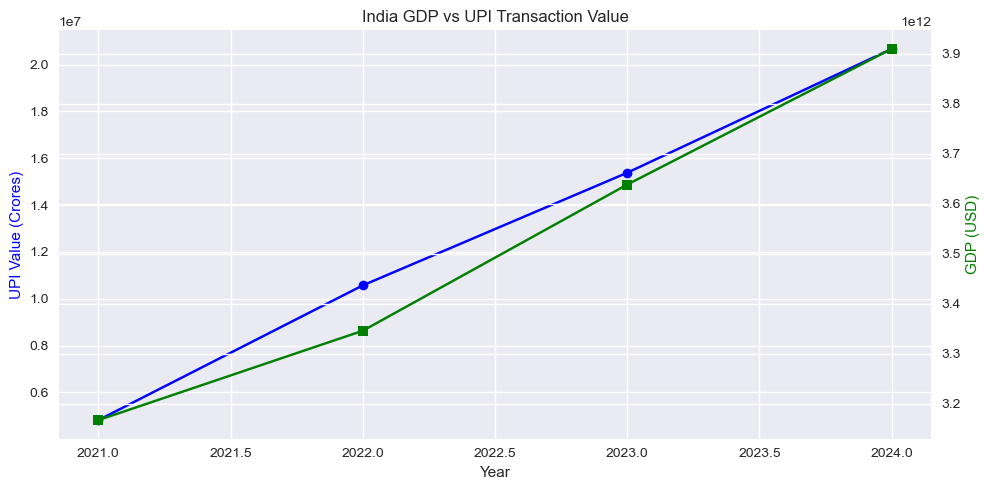

In [313]:
fig, ax1 = plt.subplots(figsize=(10,5))
plot_df = merged_df[merged_df['year']<= 2024]
ax1.plot(plot_df['year'], plot_df['value'], color='blue', marker='o', label='UPI Value')
ax1.set_xlabel('Year')
ax1.set_ylabel('UPI Value (Crores)', color='blue')

ax2 = ax1.twinx()
ax2.plot(plot_df['year'],plot_df['gdp_usd'], color='green', marker='s', label='GDP USD')
ax2.set_ylabel('GDP (USD)', color='green')

plt.title('India GDP vs UPI Transaction Value')
plt.tight_layout()
plt.show()

In [334]:
upi_yearly['volume_yoy'] = upi_yearly['volume'].pct_change()*100
upi_yearly['value_yoy'] = upi_yearly['value'].pct_change()*100
print(upi_yearly[['year','volume','volume_yoy','value','value_yoy']].round(2))

   year     volume  volume_yoy        value  value_yoy
0  2021   26236.61         NaN   4813712.90        NaN
1  2022   62506.25      138.24  10570699.46     119.60
2  2023   99362.29       58.96  15382984.77      45.52
3  2024  144868.18       45.80  20673119.25      34.39
4  2025  191710.98       32.33  25065514.67      21.25
5  2026   64738.80      -66.23   8470252.59     -66.21


###### UPI volume growth rate declined from 138% in 2022 to 32% in 2025 — not due to reduced adoption but due to market saturation. With over 2.8 billion monthly transactions by 2025, UPI has reached mass penetration across India.

##### As India's GDP grew from $3.1 trillion to $3.9 trillion between 2021 and 2024, UPI transaction value grew proportionally — confirming that digital payment adoption is directly tied to overall economic growth

In [347]:
df_clean.to_csv('upi_clean.csv', index=False)
print("exported successfully")

exported successfully


In [349]:
import os
print(os.path.exists('upi_clean.csv'))
print(os.getcwd())

True
C:\Users\Rishitha\Downloads\Product statistics- UPI


In [354]:
import pandas as pd
df_check = pd.read_csv('upi_clean.csv')
print(df_check.columns.tolist())
print(df_check.head(2))

['volume', 'avg_daily_volume', 'value', 'avg_daily_value', 'Month_dt', 'avg_transaction_value', 'volume_growth', 'year', 'volume_ma3', 'volume_ma6']
    volume  avg_daily_volume      value  avg_daily_value    Month_dt  \
0  2807.52           93.5839  547373.16       18245.7720  2021-06-01   
1  3247.82          104.7682  605883.20       19544.6194  2021-07-01   

   avg_transaction_value  volume_growth  year  volume_ma3  volume_ma6  
0             194.966789            NaN  2021         NaN         NaN  
1             186.550732       15.68288  2021         NaN         NaN  


In [356]:
cols_to_export = ['Month_dt', 'volume', 'avg_daily_volume', 'value', 'avg_daily_value', 'avg_transaction_value']
df_clean[cols_to_export].to_csv('upi_clean.csv', index=False)
print("exported successfully")

exported successfully


In [358]:
merged_df[merged_df['year'] <= 2024][['year','volume','value','gdp_usd']].to_csv('upi_gdp.csv', index=False)
print("exported")

exported
